The exclamation mark ! is used in Colab and Jupyter Notebook to run shell commands directly within the notebook.

Pip is a Python package manager used to install and manage various libraries.

Geopandas is a Python library designed for working with geospatial datasets. It integrates core libraries and dataframes, making geospatial analysis and visualization easier.

Shapely is a fundamental library within the Geopandas ecosystem that provides tools for performing geometric operations.

Matplotlib is a Python library used to create static, animated, and interactive visualizations. For example, it can be used to generate 3D plots and graphs, such as those showing the major earthquake points.

In [2]:
! pip install geopandas shapely matplotlib

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

Data extracted from USGS Earthquake Catalog in .csv format and imported it in colab.

The function read_file() is usually used to read geospatial files such as Shapefiles, GeoJSON,Spreadsheets(.csv) or other spatial formats.

.head() is a Pandas/Geopandas method that displays the first 5 rows of the dataset.:

In [5]:
data = gpd.read_file("/content/sample_data/query (3).csv")
data.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-10-04T17:43:53.456Z,52.6896,161.1177,26.47,4.8,mb,93,119,1.533,0.5,...,2025-10-04T18:38:51.040Z,"172 km ESE of Petropavlovsk-Kamchatsky, Russia",earthquake,8.26,5.631,0.055,103,reviewed,us,us
1,2025-10-04T17:38:01.871Z,51.64,160.0051,12.619,5.2,mww,221,76,1.616,0.6,...,2025-10-04T17:56:49.040Z,"180 km SE of Vilyuchinsk, Russia",earthquake,8.7,4.6,0.078,16,reviewed,us,us
2,2025-10-04T15:21:09.029Z,37.3867,141.6529,46.754,6,mww,127,49,2.884,0.77,...,2025-10-04T17:49:41.723Z,"56 km E of Tomioka, Japan",earthquake,6.37,6.276,0.039,63,reviewed,us,us
3,2025-10-04T14:15:19.580Z,39.7457,142.1935,53.247,4.5,mb,45,150,1.354,0.64,...,2025-10-04T16:11:26.040Z,"24 km ENE of Miyako, Japan",earthquake,7.7,6.396,0.102,29,reviewed,us,us
4,2025-10-04T13:12:43.941Z,51.4009,160.9921,10,4.5,mb,57,135,2.172,0.61,...,2025-10-04T16:38:59.040Z,"245 km SE of Vilyuchinsk, Russia",earthquake,11.43,1.876,0.076,51,reviewed,us,us


In [6]:
from shapely.geometry import Point

In [7]:
geomtery= [Point(xy) for xy in zip(data['longitude'], data['latitude'])]
gdf = gpd.GeoDataFrame(data, geometry=geomtery, crs="EPSG:4326")
gdf.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,geometry
0,2025-10-04T17:43:53.456Z,52.6896,161.1177,26.47,4.8,mb,93,119,1.533,0.5,...,"172 km ESE of Petropavlovsk-Kamchatsky, Russia",earthquake,8.26,5.631,0.055,103,reviewed,us,us,POINT (161.1177 52.6896)
1,2025-10-04T17:38:01.871Z,51.64,160.0051,12.619,5.2,mww,221,76,1.616,0.6,...,"180 km SE of Vilyuchinsk, Russia",earthquake,8.7,4.6,0.078,16,reviewed,us,us,POINT (160.0051 51.64)
2,2025-10-04T15:21:09.029Z,37.3867,141.6529,46.754,6,mww,127,49,2.884,0.77,...,"56 km E of Tomioka, Japan",earthquake,6.37,6.276,0.039,63,reviewed,us,us,POINT (141.6529 37.3867)
3,2025-10-04T14:15:19.580Z,39.7457,142.1935,53.247,4.5,mb,45,150,1.354,0.64,...,"24 km ENE of Miyako, Japan",earthquake,7.7,6.396,0.102,29,reviewed,us,us,POINT (142.1935 39.7457)
4,2025-10-04T13:12:43.941Z,51.4009,160.9921,10,4.5,mb,57,135,2.172,0.61,...,"245 km SE of Vilyuchinsk, Russia",earthquake,11.43,1.876,0.076,51,reviewed,us,us,POINT (160.9921 51.4009)


gdf is a GeoDataFrame (from the Geopandas library). It stores geospatial data such as points, lines, or polygons.

.plot() is a Geopandas method that creates a map or spatial plot of the data.

marker="o" -Each data point will be plotted as a small circle ("o" marker style).

color="red" - The points will be colored red.

markersize=25 - Sets the size of the markers (larger values = bigger circles).

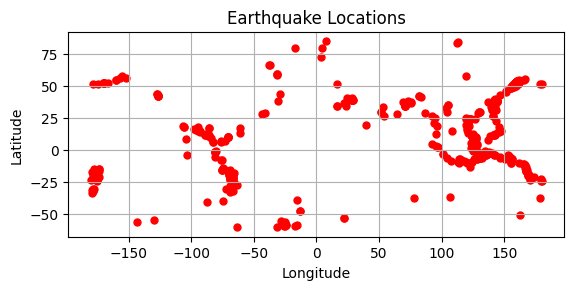

In [39]:
gdf.plot(marker="o",color="red",markersize=25)
plt.title("Earthquake Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

print(gdf) → Displays the GeoDataFrame so we can inspect the attributes and geometry of the data directly.

In [9]:
print(gdf)

                         time latitude longitude    depth  mag magType  nst  \
0    2025-10-04T17:43:53.456Z  52.6896  161.1177    26.47  4.8      mb   93   
1    2025-10-04T17:38:01.871Z    51.64  160.0051   12.619  5.2     mww  221   
2    2025-10-04T15:21:09.029Z  37.3867  141.6529   46.754    6     mww  127   
3    2025-10-04T14:15:19.580Z  39.7457  142.1935   53.247  4.5      mb   45   
4    2025-10-04T13:12:43.941Z  51.4009  160.9921       10  4.5      mb   57   
..                        ...      ...       ...      ...  ...     ...  ...   
642  2025-09-04T04:10:08.663Z  -24.347    -67.16  177.999  5.1      mb   71   
643  2025-09-04T02:40:32.948Z   4.6501   92.2411       10  4.5      mb   34   
644  2025-09-04T01:01:50.267Z   2.8829   125.861  133.403  4.6      mb   53   
645  2025-09-04T00:25:52.283Z    -2.79  130.2258   26.398  4.5      mb   35   
646  2025-09-04T00:14:28.016Z  -2.7266   130.142   19.125  4.9      mb   56   

     gap   dmin   rms  ...                         

Contextily is a Python library that provides basemaps (background map tiles) for geospatial visualizations.

It works together with Geopandas and Matplotlib to add map backgrounds like streets, satellite imagery, or terrain to the plots.

In [10]:
! pip install contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 82.0 MB/s eta 0:00:00


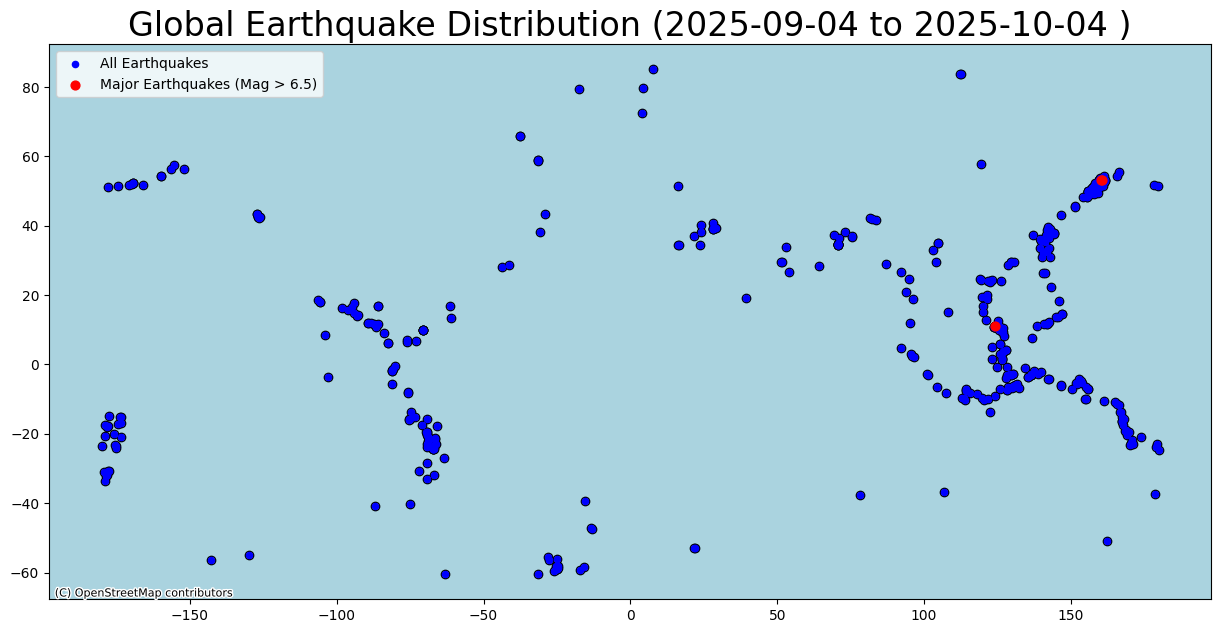

In [12]:
import pandas as pd
import contextily as ctx
ax =gdf.plot(figsize=(15, 10), color='lightgrey', edgecolor='black')

gdf.plot(ax=ax, color='blue', markersize=20, label='All Earthquakes')

gdf['mag'] = pd.to_numeric(gdf['mag'], errors='coerce')
gdf[gdf['mag'] > 6.5].plot(ax=ax, color='red', markersize=40, label='Major Earthquakes (Mag > 6.5)')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Global Earthquake Distribution (2025-09-04 to 2025-10-04 )", fontsize = 24 )
ax.legend()
plt.show()


In [13]:
df = pd.DataFrame(data)
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-10-04T17:43:53.456Z,52.6896,161.1177,26.47,4.8,mb,93,119,1.533,0.5,...,2025-10-04T18:38:51.040Z,"172 km ESE of Petropavlovsk-Kamchatsky, Russia",earthquake,8.26,5.631,0.055,103,reviewed,us,us
1,2025-10-04T17:38:01.871Z,51.64,160.0051,12.619,5.2,mww,221,76,1.616,0.6,...,2025-10-04T17:56:49.040Z,"180 km SE of Vilyuchinsk, Russia",earthquake,8.7,4.6,0.078,16,reviewed,us,us
2,2025-10-04T15:21:09.029Z,37.3867,141.6529,46.754,6,mww,127,49,2.884,0.77,...,2025-10-04T17:49:41.723Z,"56 km E of Tomioka, Japan",earthquake,6.37,6.276,0.039,63,reviewed,us,us
3,2025-10-04T14:15:19.580Z,39.7457,142.1935,53.247,4.5,mb,45,150,1.354,0.64,...,2025-10-04T16:11:26.040Z,"24 km ENE of Miyako, Japan",earthquake,7.7,6.396,0.102,29,reviewed,us,us
4,2025-10-04T13:12:43.941Z,51.4009,160.9921,10,4.5,mb,57,135,2.172,0.61,...,2025-10-04T16:38:59.040Z,"245 km SE of Vilyuchinsk, Russia",earthquake,11.43,1.876,0.076,51,reviewed,us,us


In [14]:
import plotly.express as px
import plotly.graph_objects as go

In [34]:
fig = go.Figure()
fig.add_trace(go.Scattergeo(
    lon=df['longitude'],
    lat=df['latitude'],
    text= df['place'] + "<br>mag" + df['mag'].astype(str),
    marker = dict(
        size=df['mag'].astype(float)*2,
        color=df['mag'].astype(float),
        colorscale = 'reds',
        colorbar_title= "mag",
        line_color = 'black',
        line_width=0.5,
        sizemode='area'
),
mode = 'markers'))

In [36]:
fig.update_layout(
    title_text = 'Global Earthquake Distribution (2025-09-04 to 2025-10-04)',
    geo = dict(
        scope='world',
        showland = True,
        landcolor = 'lightgrey',
        showocean = True,
        oceancolor = 'lightblue',
        projection_type = 'natural earth'
    )
)
fig.show()

In [37]:
fig.write_html("global_earthquakes.html", include_plotlyjs='cdn', full_html=True)


In [38]:
from google.colab import files
files.download("global_earthquakes.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Based on this 3D map , the regions along the Pacific Ring of Fire including countries such as Japan, western United States, Indonesia and some other countries are seeming most vulnerable to strong earthquakes.
These areas show dense clusters of high-magnitude earthquake points, reflecting intense tectonic activity where major plates meet.

This is critical for international relief planning because these regions have large populations and vital infrastructure located near active fault lines, requiring rapid response coordination and resource pre-positioning to minimize casualties and damage.